# E-Commerce Funnel Analytics: Conversion, Behavior & Revenue

# Objective

### An e-commerce platform is experiencing high traffic but relatively low conversion rates. A large number of users browse products, but only a small percentage complete purchases.
### The objective of this project is to analyze user behavior across the e-commerce funnel and identify key factors affecting conversion and revenue.The analysis focuses on understanding user journeys, session behavior, product performance, and purchasing patterns to uncover actionable insights.

## Notebook Workflow - 

###### Data Loading & Exploration
###### Data Cleaning & Quality Checks
###### Feature Engineering & Data Transformation
###### SQL-Based Analysis & Validation
###### Event Distribution Analysis
###### Funnel Conversion Analysis 
###### Cart Abandonment Analysis
###### Session Behavior Analysis
###### Time-to-Purchase Analysis
###### Category Conversion Analysis
###### Price Sensitivity & Conversion Analysis
###### Hourly Purchase Trends
###### Brand Conversion Analysis
###### Repeat Buyer Analysis
###### Session Purchase Probability 
###### User Segmentation 
###### Cohort Retention Analysis
###### Business Insights & Recommendations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/2019-Oct.csv").sample(500000, random_state=42)

#### Due to the large size of the dataset (around 42 million rows), a random sample of 500,000 rows was used for analysis. This ensures faster computation while still capturing overall user behavior patterns across the dataset.

In [3]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
10257365,2019-10-09 02:46:19 UTC,view,29900078,2059484601444729123,NaN,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa
28875143,2019-10-21 16:17:11 UTC,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e
28709595,2019-10-21 14:42:20 UTC,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3
3458568,2019-10-03 18:40:22 UTC,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c
25352815,2019-10-19 08:58:51 UTC,view,5300097,2053013563173241677,NaN,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b


In [4]:
df.shape


(500000, 9)

In [5]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 10257365 to 38106461
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     500000 non-null  object 
 1   event_type     500000 non-null  object 
 2   product_id     500000 non-null  int64  
 3   category_id    500000 non-null  int64  
 4   category_code  341032 non-null  object 
 5   brand          427692 non-null  object 
 6   price          500000 non-null  float64
 7   user_id        500000 non-null  int64  
 8   user_session   500000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 38.1+ MB


In [7]:
df.describe()


,product_id,category_id,price,user_id
count,5.000000e+05,5.000000e+05,500000.000000,5.000000e+05
mean,1.056157e+07,2.057424e+18,290.318066,5.335799e+08
std,1.189175e+07,1.849199e+16,357.246750,1.852525e+07
min,1.000978e+06,2.053014e+18,0.000000,2.194064e+08
25%,1.005157e+06,2.053014e+18,66.640000,5.159139e+08
50%,5.000504e+06,2.053014e+18,163.710000,5.297871e+08
75%,1.600088e+07,2.053014e+18,358.570000,5.516383e+08
max,6.050001e+07,2.175420e+18,2574.070000,5.662783e+08


In [8]:
df["event_time"] = pd.to_datetime(df["event_time"])

In [9]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
10257365,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,NaN,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa
28875143,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e
28709595,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3
3458568,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c
25352815,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,NaN,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b


In [10]:
df["hour"] = df["event_time"].dt.hour
df["day"] = df["event_time"].dt.day
df["day_of_week"] = df["event_time"].dt.day_name()

In [11]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day,day_of_week
10257365,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,NaN,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2,9,Wednesday
28875143,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,16,21,Monday
28709595,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,14,21,Monday
3458568,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,18,3,Thursday
25352815,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,NaN,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,8,19,Saturday


In [12]:
df.duplicated().sum()

9

In [13]:
df = df.drop_duplicates()

In [14]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    158966
brand             72307
price                 0
user_id               0
user_session          0
hour                  0
day                   0
day_of_week           0
dtype: int64

In [15]:
df["brand"] = df["brand"].fillna("unknown")
df["category_code"] = df["category_code"].fillna("unknown")

In [16]:
df[df["price"] <= 0]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day,day_of_week
40521785,2019-10-30 10:56:07+00:00,view,42000076,2102307650380235197,unknown,unknown,0.0,515907473,3d9220f1-f8b1-4d0b-9f7b-4aa37c7793c1,10,30,Wednesday
17249180,2019-10-13 17:49:30+00:00,view,28102239,2053013564918072245,unknown,unknown,0.0,554663860,4cc11381-edda-4091-a24d-a3ef669a5146,17,13,Sunday
2174068,2019-10-02 16:24:05+00:00,view,5100862,2053013553341792533,electronics.clocks,unknown,0.0,541806130,5770811d-c02d-4b07-935e-1b7327f8a0ca,16,2,Wednesday
40471602,2019-10-30 10:06:28+00:00,view,16800606,2053013558316237377,furniture.kitchen.table,unknown,0.0,513276551,aca456f1-df92-436c-8e05-10d1a1427e15,10,30,Wednesday
34527893,2019-10-25 17:18:40+00:00,view,1800729,2053013554415534427,electronics.video.tv,unknown,0.0,525101204,5b6691e6-633f-447d-bab0-17478173a85f,17,25,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...
4881173,2019-10-04 18:57:30+00:00,view,10800090,2053013554994348409,unknown,unknown,0.0,515272365,ed085242-c8e1-4eaf-aae0-b038a4b2a38d,18,4,Friday
2679713,2019-10-03 06:45:22+00:00,view,1002923,2053013555631882655,electronics.smartphone,unknown,0.0,556264701,074578c3-d518-49ca-8ef1-42908af40beb,6,3,Thursday
10331110,2019-10-09 04:15:54+00:00,view,52100001,2137704926053138958,unknown,unknown,0.0,522694904,592259a8-7605-47da-9b5f-f7d1527e3d44,4,9,Wednesday
9629793,2019-10-08 13:28:11+00:00,view,21407430,2053013561579406073,electronics.clocks,unknown,0.0,558082917,dc93357b-1142-45ca-a086-d875901e5344,13,8,Tuesday


#### Out of the 500,000 sampled records, 740 rows (~0.15%) contained zero or negative prices, which likely represent data entry errors or missing values.

In [17]:
df = df[df["price"] > 0]

In [18]:
df["event_type"].value_counts()

event_type
view        479548
cart         10852
purchase      8851
Name: count, dtype: int64

In [19]:
df["user_id"].nunique()

364324

In [20]:
df["user_session"].nunique()

464727

In [21]:
df.to_csv("cleaned_data.csv", index=False)

# SQL Analysis

### SQL queries were used to simulate real-world data extraction workflows where data is typically stored in databases. The following queries replicate key analyses such as funnel conversion, revenue distribution, and user behavior.

In [22]:
import sqlite3

In [23]:
conn = sqlite3.connect("ecommerce.db")
df.to_sql("events", conn, if_exists="replace", index=False)

499251

In [24]:
query = "SELECT * FROM events LIMIT 5"
pd.read_sql(query, conn)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day,day_of_week
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2,9,Wednesday
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,16,21,Monday
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,14,21,Monday
3,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,18,3,Thursday
4,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,8,19,Saturday


In [25]:
query = """
SELECT event_type, COUNT(*) as count
FROM events
GROUP BY event_type
"""

pd.read_sql(query, conn)

,event_type,count
0,cart,10852
1,purchase,8851
2,view,479548


#### SQL Insight — Event Distribution

#### This query calculates the total number of events for each interaction type (view, cart, purchase). It helps understand how users interact with the platform at a high level and highlights that most interactions are concentrated in product views.

In [26]:
query = """
SELECT
COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS views,
COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) AS carts,
COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS purchases
FROM events
"""

pd.read_sql(query, conn)

,views,carts,purchases
0,352335,10426,8536


In [27]:
query = """
SELECT
COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS views,
COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) AS carts,
COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS purchases,

COUNT(DISTINCT CASE WHEN event_type = 'cart' THEN user_id END) * 1.0 /
COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS cart_conversion,

COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) * 1.0 /
COUNT(DISTINCT CASE WHEN event_type = 'view' THEN user_id END) AS purchase_conversion

FROM events
"""

pd.read_sql(query, conn)

,views,carts,purchases,cart_conversion,purchase_conversion
0,352335,10426,8536,0.029591,0.024227


#### SQL Insight — Funnel Conversion

#### This query calculates the number of unique users at each stage of the funnel (view, cart, purchase) and computes the conversion rates. It helps identify how many users progress through each stage and highlights where the biggest drop-offs occur in the user journey.

In [28]:
query = """
SELECT
CASE
    WHEN price < 50 THEN '0-50'
    WHEN price < 100 THEN '50-100'
    WHEN price < 200 THEN '100-200'
    WHEN price < 500 THEN '200-500'
    WHEN price < 1000 THEN '500-1000'
    ELSE '1000+'
END AS price_range,
SUM(price) AS revenue
FROM events
WHERE event_type = 'purchase'
GROUP BY price_range
ORDER BY revenue DESC
"""

pd.read_sql(query, conn)

,price_range,revenue
0,1000+,753133.17
1,500-1000,746302.81
2,200-500,720565.46
3,100-200,362788.52
4,50-100,78778.04
5,0-50,42448.53


#### SQL Insight — Revenue by Price Range

#### This query calculates total revenue generated from different price ranges. It helps identify which segments contribute most to overall revenue and shows that higher-priced products often contribute significantly despite lower volume.

In [29]:
query = """
SELECT hour, COUNT(*) AS purchases
FROM events
WHERE event_type = 'purchase'
GROUP BY hour
ORDER BY hour
"""

pd.read_sql(query, conn)

,hour,purchases
0,0,45
1,1,85
2,2,139
3,3,335
4,4,489
5,5,546
6,6,617
7,7,639
8,8,657
9,9,644


#### SQL Insight — Purchases by Hour

#### This query analyzes how purchase activity varies throughout the day. It helps identify peak hours when users are most likely to complete purchases, which can be useful for scheduling promotions and marketing campaigns.

# Event Distribution Analysis

In [30]:
df["event_type"].value_counts()

event_type
view        479548
cart         10852
purchase      8851
Name: count, dtype: int64

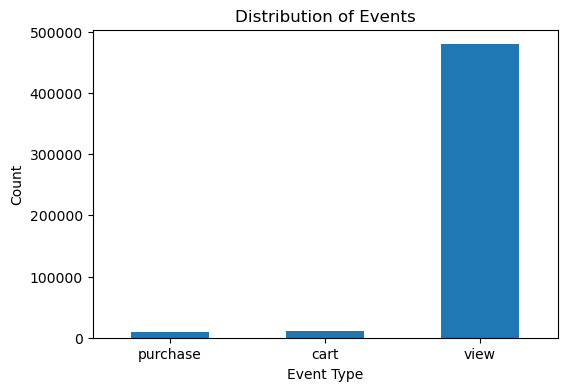

In [31]:
plt.figure(figsize=(6,4))

df["event_type"].value_counts().sort_values().plot(kind="bar")

plt.title("Distribution of Events")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

### Most of the user activity is focused on browsing products, while only a small number of users move ahead to add items to their cart or make a purchase. This shows that many users lose interest early in the process, possibly because they don’t find the product appealing enough or don’t feel motivated to continue further.

# Funnel Conversion Analysis

In [32]:
#how many unique users did each event

view_users = df[df["event_type"] == "view"]["user_id"].nunique()
purchase_users = df[df["event_type"] == "purchase"]["user_id"].nunique()
cart_users = df[df["event_type"] == "cart"]["user_id"].nunique()

print(f'''Number of users doing,
views = {view_users}
purchases = {purchase_users}
cart = {cart_users} ''')

Number of users doing,
views = 352335
purchases = 8536
cart = 10426 


In [33]:
cart_conversion = cart_users / view_users
purchase_conversion = purchase_users / view_users

cart_conversion, purchase_conversion

(0.029591156144010672, 0.024226943108121533)

### Only 2.95% of the users who view the products add them to the cart, and only 2.42% of the users who view complete the purchase, highlighting major drop-offs in the user journey.

In [34]:
funnel = pd.DataFrame({
    "Stage": ["View", "Cart", "Purchase"],
    "Users": [view_users, cart_users, purchase_users]
})

funnel

,Stage,Users
0,View,352335
1,Cart,10426
2,Purchase,8536


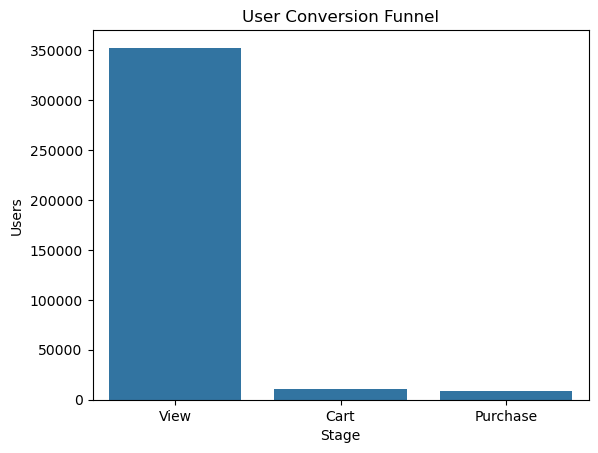

In [35]:
sns.barplot(x="Stage", y="Users", data=funnel)

plt.title("User Conversion Funnel")

plt.show()

### While the platform attracts a high number of product views, only a small portion of users continue to the cart and purchase stages. This highlights a clear gap between user interest and actual buying behavior, indicating that many users do not convert despite showing initial interest.

# Cart Abandonment Analysis

In [36]:
#we have already calculated unique users who added to cart and who purchased
cart_abandonment = (cart_users - purchase_users) / cart_users

cart_abandonment

0.18127757529253788

### Around 18% of users who added products to their cart did not complete the purchase. This shows that even after showing clear intent to buy, a significant number of users drop off at the final stage, possibly due to factors like pricing, additional charges, or friction in the checkout process.

# Session Behavior Analysis

In [37]:
session_time = df.groupby("user_session")["event_time"].agg(["min","max"])
session_time["duration"] = session_time["max"] - session_time["min"]

session_time.head()

,min,max,duration
user_session,,,
00000056-a206-40dd-b174-a072550fa38c,2019-10-31 06:23:52+00:00,2019-10-31 06:23:52+00:00,0 days
000001fd-1f89-45e8-a3ce-fe3218cabfad,2019-10-25 08:35:30+00:00,2019-10-25 08:35:30+00:00,0 days
000003eb-b63e-45d9-9f26-f229057c654a,2019-10-03 11:28:52+00:00,2019-10-03 11:28:52+00:00,0 days
000011ef-e9fc-4920-96cd-2534bda3cdc2,2019-10-03 13:18:43+00:00,2019-10-03 13:18:43+00:00,0 days
000024a4-d991-4020-a163-f6fdcc80efac,2019-10-07 19:47:08+00:00,2019-10-07 19:47:08+00:00,0 days


In [38]:
session_time["duration"].mean()

Timedelta('0 days 00:01:16.440038990')

### On average, users spend only a short amount of time (~ 1-2 minutes) in a session, which suggests that most visits are quick and possibly focused on browsing rather than deep engagement. This could indicate that users are either finding what they need quickly or leaving the platform without exploring much further.

# Time-to-Purchase Analysis

In [39]:
purchase_sessions = df[df["event_type"] == "purchase"]["user_session"].unique()
purchase_sessions

array(['ce6278c1-fd32-409b-97ad-b4bb248ab489',
       '3aad8428-6ab5-4ece-a8ff-657d28a57dec',
       '6b323904-cf92-4920-88c0-4bed2f17879a', ...,
       'ddc5d7a8-4692-48ed-b622-af61344382d3',
       '55575977-d123-4a6d-85a5-080bc836de86',
       '9f97e3ae-64bf-4b8b-847c-f47eebbbb7c7'], dtype=object)

In [40]:
purchase_df = df[df["user_session"].isin(purchase_sessions)]
purchase_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day,day_of_week
4138189,2019-10-04 10:18:54+00:00,purchase,5801387,2053013553945772349,electronics.audio.subwoofer,pioneer,87.26,556352665,ce6278c1-fd32-409b-97ad-b4bb248ab489,10,4,Friday
3673006,2019-10-04 03:55:44+00:00,purchase,9000200,2053013554096767303,computers.components.power_supply,aerocool,24.43,512984809,3aad8428-6ab5-4ece-a8ff-657d28a57dec,3,4,Friday
16017257,2019-10-13 05:15:35+00:00,purchase,1005115,2053013555631882655,electronics.smartphone,apple,1003.85,515936967,6b323904-cf92-4920-88c0-4bed2f17879a,5,13,Sunday
35923172,2019-10-26 17:51:28+00:00,purchase,26300739,2053013563584283495,unknown,lucente,510.70,518731424,977f1d3f-8b40-4c31-acf1-def8bfae5931,17,26,Saturday
23856508,2019-10-18 09:00:21+00:00,purchase,1002544,2053013555631882655,electronics.smartphone,apple,460.05,518198671,4e26d4f1-b0ee-4362-90ac-4de25e369549,9,18,Friday


In [41]:
purchase_time = purchase_df.groupby("user_session")["event_time"].agg(["min", "max"])
purchase_time.head()

,min,max
user_session,,
00197ff4-d906-4589-aa0b-ecbf2f975202,2019-10-28 09:21:57+00:00,2019-10-28 09:21:57+00:00
001ee01e-10af-461d-a963-bcedeaf9821d,2019-10-15 07:29:10+00:00,2019-10-15 07:29:10+00:00
0029edaf-0d77-47de-80e8-1ba6e2f5a8c8,2019-10-14 19:21:04+00:00,2019-10-14 19:21:04+00:00
00319638-92bb-4b6a-96c0-4103788720ea,2019-10-25 21:13:20+00:00,2019-10-25 21:13:40+00:00
0039218b-98b8-4906-a233-6bf44220b415,2019-10-13 14:51:21+00:00,2019-10-13 14:51:21+00:00


In [42]:
purchase_time["time_to_purchase"] = purchase_time["max"] - purchase_time["min"]
purchase_time.head()

,min,max,time_to_purchase
user_session,,,
00197ff4-d906-4589-aa0b-ecbf2f975202,2019-10-28 09:21:57+00:00,2019-10-28 09:21:57+00:00,0 days 00:00:00
001ee01e-10af-461d-a963-bcedeaf9821d,2019-10-15 07:29:10+00:00,2019-10-15 07:29:10+00:00,0 days 00:00:00
0029edaf-0d77-47de-80e8-1ba6e2f5a8c8,2019-10-14 19:21:04+00:00,2019-10-14 19:21:04+00:00,0 days 00:00:00
00319638-92bb-4b6a-96c0-4103788720ea,2019-10-25 21:13:20+00:00,2019-10-25 21:13:40+00:00,0 days 00:00:20
0039218b-98b8-4906-a233-6bf44220b415,2019-10-13 14:51:21+00:00,2019-10-13 14:51:21+00:00,0 days 00:00:00


In [43]:
purchase_time["time_to_purchase"].mean()

Timedelta('0 days 00:00:52.585890612')

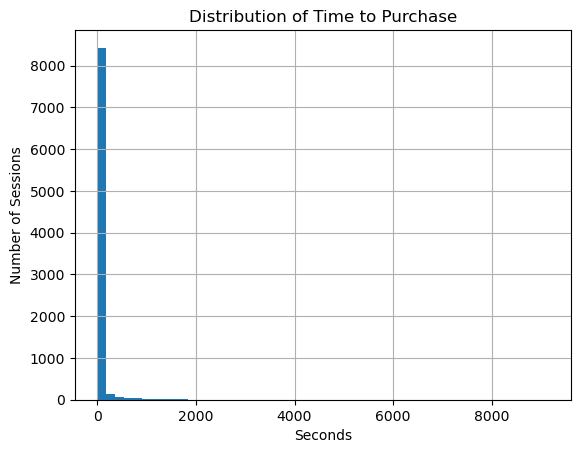

In [44]:
purchase_time["time_to_purchase"].dt.seconds.hist(bins=50)

plt.title("Distribution of Time to Purchase")
plt.xlabel("Seconds")
plt.ylabel("Number of Sessions")

plt.show()

### Most purchases happen very quickly within a session, often within a short span of time (~ 1 minute). This suggests that users who decide to buy usually do so without much delay, indicating more impulsive or already-decided purchases rather than long consideration.

# Category Conversion Analysis

In [45]:
views_cat = df[df["event_type"] == "view"].groupby("category_code")["user_id"].count()
views_cat.head()

category_code
accessories.bag         2267
accessories.umbrella      43
accessories.wallet       514
apparel.belt              16
apparel.costume         1632
Name: user_id, dtype: int64

In [46]:
purchase_cat = df[df["event_type"] == "purchase"].groupby("category_code")["user_id"].count()

In [47]:
category_funnel = pd.DataFrame({
    "views" : views_cat,
"purchases" : purchase_cat}).fillna(0)

In [48]:
category_funnel

,views,purchases
category_code,,
accessories.bag,2267,21.0
accessories.umbrella,43,1.0
accessories.wallet,514,2.0
apparel.belt,16,0.0
apparel.costume,1632,6.0
...,...,...
sport.snowboard,54,0.0
sport.tennis,47,0.0
sport.trainer,411,3.0


In [49]:
category_funnel["conversion_rate"] = category_funnel["purchases"] / category_funnel["views"]
category_funnel

,views,purchases,conversion_rate
category_code,,,
accessories.bag,2267,21.0,0.009263
accessories.umbrella,43,1.0,0.023256
accessories.wallet,514,2.0,0.003891
apparel.belt,16,0.0,0.000000
apparel.costume,1632,6.0,0.003676
...,...,...,...
sport.snowboard,54,0.0,0.000000
sport.tennis,47,0.0,0.000000
sport.trainer,411,3.0,0.007299


In [50]:
category_funnel.sort_values("conversion_rate", ascending=False).head(10)

,views,purchases,conversion_rate
category_code,,,
medicine.tools.tonometer,180,7.0,0.038889
electronics.smartphone,125295,3981.0,0.031773
electronics.audio.headphone,11854,345.0,0.029104
appliances.personal.scales,688,19.0,0.027616
computers.peripherals.mouse,795,20.0,0.025157
stationery.cartrige,81,2.0,0.024691
computers.ebooks,331,8.0,0.024169
appliances.kitchen.microwave,1969,46.0,0.023362
accessories.umbrella,43,1.0,0.023256


#### Categories with very small view counts show high conversion rates but may not be statistically reliable due to limited sample size.

In [51]:
category_filtered = category_funnel[category_funnel["views"] > 1000]

category_filtered.sort_values("conversion_rate", ascending=False).head(10)

,views,purchases,conversion_rate
category_code,,,
electronics.smartphone,125295,3981.0,0.031773
electronics.audio.headphone,11854,345.0,0.029104
appliances.kitchen.microwave,1969,46.0,0.023362
appliances.iron,1779,39.0,0.021922
computers.peripherals.printer,1719,36.0,0.020942
appliances.environment.water_heater,1556,32.0,0.020566
electronics.video.tv,12404,253.0,0.020397
appliances.kitchen.washer,9717,179.0,0.018421
electronics.tablet,3621,65.0,0.017951


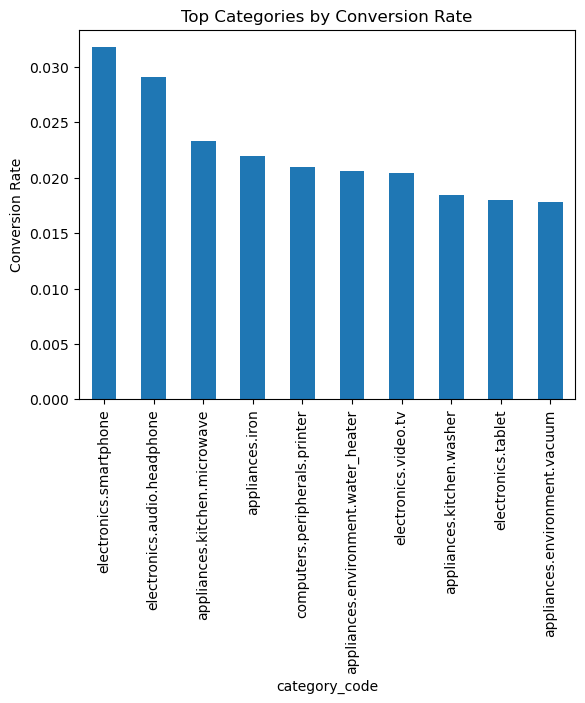

In [52]:
top_categories = category_filtered.sort_values("conversion_rate", ascending=False).head(10)

top_categories["conversion_rate"].plot(kind="bar")

plt.title("Top Categories by Conversion Rate")
plt.ylabel("Conversion Rate")

plt.show()

### Electronics products such as smartphones and headphones show strong conversion performance. Smartphones generate both the highest traffic and a high purchase rate, indicating strong user demand and purchase intent in this category.

# Price Sensitivity Analysis

In [53]:
df["price"].describe()

count    499251.000000
mean        290.746964
std         357.338262
min           0.770000
25%          66.760000
50%         164.480000
75%         358.570000
max        2574.070000
Name: price, dtype: float64

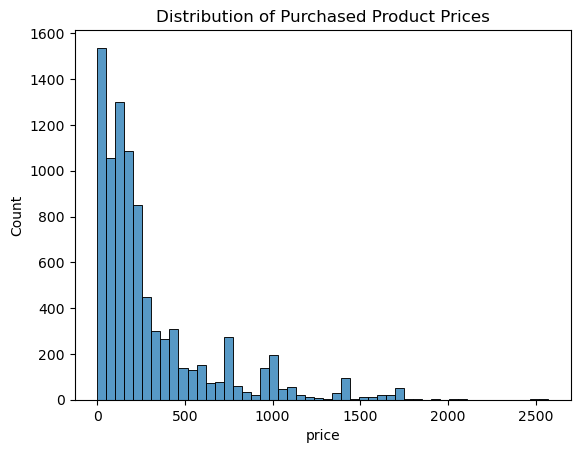

In [54]:
sns.histplot(df[df["event_type"]=="purchase"]["price"], bins=50)

plt.title("Distribution of Purchased Product Prices")

plt.show()

In [55]:
df["price_range"] = pd.cut(
    df["price"],
    bins=[0,50,100,200,500,1000,5000],
    labels=["0-50","50-100","100-200","200-500","500-1000","1000+"]
)

In [56]:
# how many users viewed and purchased in each prize range
views_price = df[df["event_type"]=="view"].groupby("price_range")["user_id"].count()
purchase_price = df[df["event_type"]=="purchase"].groupby("price_range")["user_id"].count()

C:\Users\ACER\AppData\Local\Temp\ipykernel_17884\4061572240.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  views_price = df[df["event_type"]=="view"].groupby("price_range")["user_id"].count()
C:\Users\ACER\AppData\Local\Temp\ipykernel_17884\4061572240.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purchase_price = df[df["event_type"]=="purchase"].groupby("price_range")["user_id"].count()


In [57]:
price_conversion = pd.DataFrame({
    "views": views_price,
    "purchases": purchase_price
}).fillna(0)

price_conversion

,views,purchases
price_range,,
0-50,89874,1428
50-100,77271,1089
100-200,108572,2412
200-500,124602,2296
500-1000,51910,1042
1000+,27319,584


In [58]:
price_conversion["conversion_rate"] = price_conversion["purchases"] / price_conversion["views"]

price_conversion

,views,purchases,conversion_rate
price_range,,,
0-50,89874,1428,0.015889
50-100,77271,1089,0.014093
100-200,108572,2412,0.022216
200-500,124602,2296,0.018427
500-1000,51910,1042,0.020073
1000+,27319,584,0.021377


### Users are more likely to purchase products in the mid-price range (around 100–200), while very cheap products convert less. This suggests that users prefer items that offer a balance between price and perceived value.

In [59]:
purchase_df = df[df["event_type"] == "purchase"]

revenue_price = purchase_df.groupby("price_range")["price"].sum()

price_conversion["revenue"] = revenue_price

price_conversion

C:\Users\ACER\AppData\Local\Temp\ipykernel_17884\3320571094.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_price = purchase_df.groupby("price_range")["price"].sum()


,views,purchases,conversion_rate,revenue
price_range,,,,
0-50,89874,1428,0.015889,42448.53
50-100,77271,1089,0.014093,78778.04
100-200,108572,2412,0.022216,362788.52
200-500,124602,2296,0.018427,720565.46
500-1000,51910,1042,0.020073,746302.81
1000+,27319,584,0.021377,753133.17


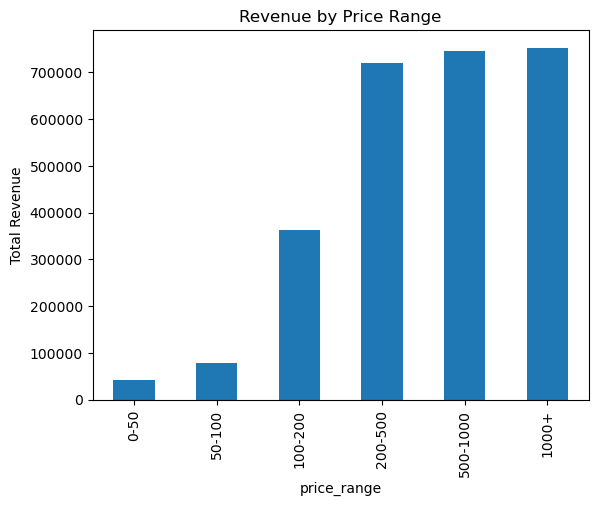

In [60]:
price_conversion["revenue"].plot(kind="bar")

plt.title("Revenue by Price Range")
plt.ylabel("Total Revenue")

plt.show()

### Most of the revenue comes from mid to high-priced products, showing that higher-value items contribute more to overall revenue despite fewer purchases.

# Hourly Purchase Behavior

In [61]:
purchase_hour = df[df["event_type"]=="purchase"].groupby("hour")["user_id"].count()

purchase_hour

hour
0      45
1      85
2     139
3     335
4     489
5     546
6     617
7     639
8     657
9     644
10    683
11    557
12    505
13    445
14    432
15    451
16    414
17    394
18    312
19    196
20    115
21     70
22     44
23     37
Name: user_id, dtype: int64

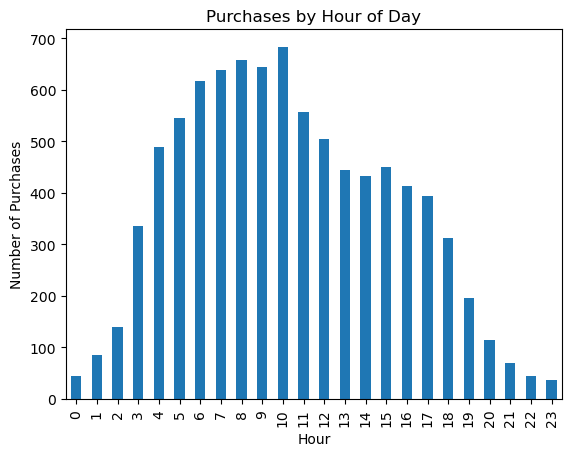

In [62]:
purchase_hour.plot(kind="bar")

plt.title("Purchases by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Purchases")

plt.show()

### Purchases peak during the morning to early afternoon hours, particularly around 10 AM. This indicates that users are more likely to buy during this time, making it an ideal window for running promotions, ads, or sending notifications to maximize conversions.

# Brand Conversion Analysis

In [63]:
views_brand = df[df["event_type"] == "view"].groupby("brand")["user_id"].nunique()
purchase_brand = df[df["event_type"] == "purchase"].groupby("brand")["user_id"].nunique()

In [64]:
brand_funnel = pd.DataFrame({
    "views" : views_brand,
    "purchases" : purchase_brand}).fillna(0)

brand_funnel

,views,purchases
brand,,
a-case,89.0,1.0
a-derma,3.0,0.0
a-elita,1.0,0.0
a-mega,9.0,0.0
aardwolf,1.0,0.0
...,...,...
zoops,1.0,0.0
zorg,6.0,0.0
zotac,15.0,0.0


In [65]:
brand_funnel["conversion_rate"] = brand_funnel["purchases"] / brand_funnel["views"]

brand_funnel.head()

,views,purchases,conversion_rate
brand,,,
a-case,89.0,1.0,0.011236
a-derma,3.0,0.0,0.000000
a-elita,1.0,0.0,0.000000
a-mega,9.0,0.0,0.000000
aardwolf,1.0,0.0,0.000000


In [66]:
brand_filtered = brand_funnel[brand_funnel["views"] > 1000]

brand_filtered.sort_values("conversion_rate", ascending = False).head()

,views,purchases,conversion_rate
brand,,,
apple,39892.0,1616.0,0.040509
samsung,51569.0,1961.0,0.038027
cordiant,3825.0,133.0,0.034771
nokian,1981.0,65.0,0.032812
viatti,1049.0,29.0,0.027645


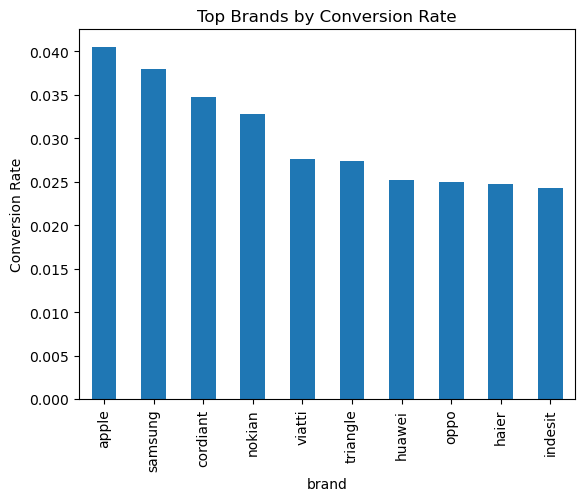

In [67]:
top_brands = brand_filtered.sort_values("conversion_rate", ascending=False).head(10)

top_brands["conversion_rate"].plot(kind="bar")

plt.title("Top Brands by Conversion Rate")
plt.ylabel("Conversion Rate")

plt.show()

### Apple and Samsung dominate the platform in both traffic and conversion rates. Apple achieves the highest conversion rate (4.05%), suggesting stronger brand trust and purchase intent compared to other brands.

# Repeat buyer analysis

In [68]:
purchase_df = df[df["event_type"] == "purchase"]

repeat_buyers = purchase_df.groupby("user_id").size()
repeat_buyers.head()

user_id
439111345    1
446080337    1
460983696    1
468406319    1
488123390    1
dtype: int64

In [69]:
repeat_buyers.describe()

count    8536.000000
mean        1.036903
std         0.233005
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
dtype: float64

In [70]:
repeat_count = (repeat_buyers > 1).sum()
repeat_count

261

In [71]:
total_buyers = purchase_df["user_id"].nunique()

In [72]:
repeat_rate = repeat_count / total_buyers
repeat_rate

0.03057638238050609

### Only a small percentage of users (3-4%) make repeat purchases, while most users buy just once. This suggests that the platform is not retaining customers effectively, highlighting an opportunity to improve customer engagement and encourage repeat buying.

# Session Purchase Probability

In [73]:
purchase_sessions = df[df["event_type"]=="purchase"]["user_session"].nunique()
total_sessions = df["user_session"].nunique()


In [74]:
session_purchase_probability = purchase_sessions / total_sessions


In [75]:
session_purchase_probability

0.01900255418772742

### Only a small share of sessions (~ 1-2%) result in a purchase, indicating that while users are visiting the platform, most do not complete the buying process.

# User Segmentation


In [76]:
user_behaviour = df.groupby(["user_id", "event_type"]).size()
user_behaviour

user_id    event_type
219406386  view          1
240236728  view          1
244951053  view          1
251869926  view          1
253578028  view          1
                        ..
566273508  view          1
566274809  view          1
566275716  view          1
566277464  view          1
566278257  view          1
Length: 371297, dtype: int64

In [77]:
user_behaviour = user_behaviour.unstack().fillna(0)

user_behaviour.head()

event_type,cart,purchase,view
user_id,,,
219406386,0.0,0.0,1.0
240236728,0.0,0.0,1.0
244951053,0.0,0.0,1.0
251869926,0.0,0.0,1.0
253578028,0.0,0.0,1.0


In [78]:
def classify_user(row):

    if row["purchase"] > 0:
        return "Buyer"

    elif row["cart"] > 0:
        return "Cart Abandoner"

    else:
        return "Viewer"

In [79]:
user_behaviour["segment"] = user_behaviour.apply(classify_user, axis=1)

user_behaviour.head()

event_type,cart,purchase,view,segment
user_id,,,,
219406386,0.0,0.0,1.0,Viewer
240236728,0.0,0.0,1.0,Viewer
244951053,0.0,0.0,1.0,Viewer
251869926,0.0,0.0,1.0,Viewer
253578028,0.0,0.0,1.0,Viewer


In [80]:
user_segments = user_behaviour["segment"].value_counts()

user_segments

segment
Viewer            345803
Cart Abandoner      9985
Buyer               8536
Name: count, dtype: int64

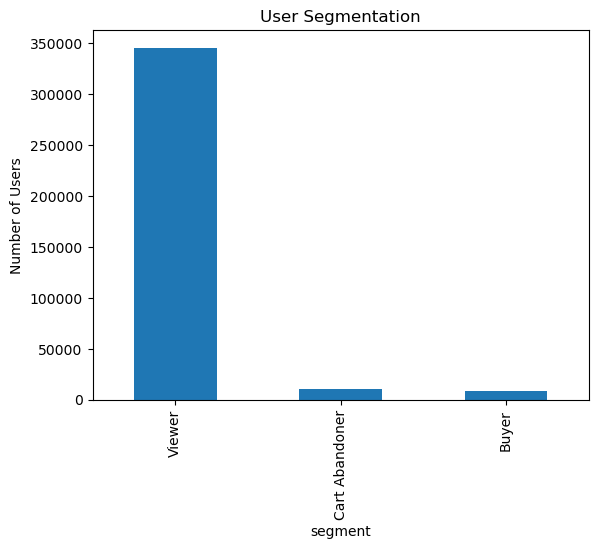

In [81]:
user_segments.plot(kind="bar")

plt.title("User Segmentation")
plt.ylabel("Number of Users")

plt.show()

### A large portion of users only browse products without progressing further, while a smaller group adds items to cart or completes purchases. The presence of cart abandoners highlights potential friction in the checkout process.

# Cohort Retention Analysis

In [82]:
df["date"] = df["event_time"].dt.date

In [83]:
first_visit = df.groupby("user_id")["date"].min()
first_visit.name = "cohort_date"
first_visit

user_id
219406386    2019-10-16
240236728    2019-10-13
244951053    2019-10-01
251869926    2019-10-23
253578028    2019-10-15
                ...    
566273508    2019-10-31
566274809    2019-10-31
566275716    2019-10-31
566277464    2019-10-31
566278257    2019-10-31
Name: cohort_date, Length: 364324, dtype: object

In [84]:
df = df.merge(first_visit, on="user_id")
df.head()

# Or we could have simply use transform
# df["cohort_date"] = df.groupby("user_id")["date"].transform("min")

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day,day_of_week,price_range,date,cohort_date
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown,peda,1647.40,532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2,9,Wednesday,1000+,2019-10-09,2019-10-09
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,16,21,Monday,200-500,2019-10-21,2019-10-21
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,14,21,Monday,200-500,2019-10-21,2019-10-21
3,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,18,3,Thursday,50-100,2019-10-03,2019-10-03
4,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,8,19,Saturday,0-50,2019-10-19,2019-10-19


In [85]:
df["date"] = pd.to_datetime(df["date"])
df["cohort_date"] = pd.to_datetime(df["cohort_date"])

df["days_since_first"] = (df["date"] - df["cohort_date"]).dt.days

In [86]:
cohort = df.groupby(["cohort_date", "days_since_first"])["user_id"].nunique()
cohort

cohort_date  days_since_first
2019-10-01   0                   13069
             1                     455
             2                     315
             3                     343
             4                     291
                                 ...  
2019-10-29   1                     214
             2                     133
2019-10-30   0                    9289
             1                     221
2019-10-31   0                    9702
Name: user_id, Length: 496, dtype: int64

In [87]:
cohort = cohort.unstack().fillna(0)
cohort.head()

days_since_first,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
cohort_date,,,,,,,,,,,,,,,,,,,,,
2019-10-01,13069.0,455.0,315.0,343.0,291.0,252.0,217.0,221.0,213.0,209.0,...,180.0,151.0,168.0,192.0,178.0,154.0,145.0,110.0,123.0,130.0
2019-10-02,12058.0,408.0,321.0,281.0,237.0,217.0,204.0,215.0,194.0,220.0,...,152.0,144.0,140.0,124.0,146.0,117.0,129.0,147.0,131.0,0.0
2019-10-03,11218.0,442.0,295.0,271.0,208.0,212.0,193.0,196.0,212.0,223.0,...,132.0,148.0,133.0,154.0,135.0,121.0,106.0,129.0,0.0,0.0
2019-10-04,13588.0,450.0,291.0,280.0,257.0,215.0,204.0,245.0,230.0,257.0,...,167.0,143.0,132.0,145.0,130.0,126.0,142.0,0.0,0.0,0.0
2019-10-05,12709.0,371.0,249.0,233.0,195.0,188.0,208.0,221.0,257.0,199.0,...,156.0,156.0,106.0,112.0,117.0,127.0,0.0,0.0,0.0,0.0


In [88]:
cohort_retention = cohort.divide(cohort[0], axis=0)
cohort_retention.head()

days_since_first,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
cohort_date,,,,,,,,,,,,,,,,,,,,,
2019-10-01,1.0,0.034815,0.024103,0.026245,0.022266,0.019282,0.016604,0.016910,0.016298,0.015992,...,0.013773,0.011554,0.012855,0.014691,0.013620,0.011784,0.011095,0.008417,0.009412,0.009947
2019-10-02,1.0,0.033836,0.026621,0.023304,0.019655,0.017996,0.016918,0.017830,0.016089,0.018245,...,0.012606,0.011942,0.011611,0.010284,0.012108,0.009703,0.010698,0.012191,0.010864,0.000000
2019-10-03,1.0,0.039401,0.026297,0.024158,0.018542,0.018898,0.017204,0.017472,0.018898,0.019879,...,0.011767,0.013193,0.011856,0.013728,0.012034,0.010786,0.009449,0.011499,0.000000,0.000000
2019-10-04,1.0,0.033117,0.021416,0.020606,0.018914,0.015823,0.015013,0.018031,0.016927,0.018914,...,0.012290,0.010524,0.009714,0.010671,0.009567,0.009273,0.010450,0.000000,0.000000,0.000000
2019-10-05,1.0,0.029192,0.019592,0.018333,0.015343,0.014793,0.016366,0.017389,0.020222,0.015658,...,0.012275,0.012275,0.008341,0.008813,0.009206,0.009993,0.000000,0.000000,0.000000,0.000000


### User retention drops significantly after the first interaction, indicating that most users do not return to the platform. This suggests an opportunity to improve engagement strategies such as notifications, offers, or personalized recommendations.

# KEY FINDINGS:

#### 1) Most users interact with the platform only at the browsing stage, and only a small percentage (~ 2-3%) move forward to purchase, indicating a major drop-off early in the funnel.

#### 2) Only a small fraction of users who view products actually complete a purchase, showing a clear gap between interest and actual buying behavior.

#### 3) Users spend a short time (~ 1-2 minutes) in each session, and most purchases happen quickly, suggesting that buying decisions are usually made within the same session rather than after long consideration.

#### 4) Electronics categories, especially smartphones and headphones, generate both high traffic and strong conversions, making them key drivers of platform performance.

#### 5) Mid-priced products tend to convert better than very cheap ones, indicating that users focus more on value rather than just low price.

#### 6) Most of the revenue comes from mid to high-priced products, showing that higher-value items play an important role in overall business growth.

#### 7) Purchase activity is highest during morning to early afternoon hours, especially around 10 AM, suggesting that users are more likely to buy during this time.

#### 8) Brands like Apple and Samsung drive strong traffic as well as conversions, indicating high customer trust and brand preference.

#### 9) Most users do not return after their first interaction, and only a small percentage (~3-4%) become repeat buyers, highlighting low user retention.

#### 10) A large number of users only browse products without taking further action, while some users add items to the cart but do not complete the purchase, indicating possible friction in the buying process.

# RECOMMENDTIONS 

#### 1) Improve product pages and overall user experience to encourage users to move beyond browsing, as the biggest drop-off happens at this stage.

#### 2) Simplify the checkout process to reduce cart abandonment and make the purchase journey smoother.

#### 3) Focus marketing efforts on high-performing categories like electronics, which already show strong conversion potential.

#### 4) Promote mid-range and high-value products, as they contribute significantly to both conversions and revenue.

#### 5) Run targeted campaigns during peak hours (morning to early afternoon) to maximize purchase activity.

#### 6) Introduce strategies to improve retention, such as personalized recommendations, offers, and reminders, since most users do not return.

#### 7) Target users who abandon carts with discounts or follow-up notifications to recover potential lost sales.

#### 8) Strengthen partnerships or promotions with high-performing brands like Apple and Samsung to further boost conversions.